# CHAPTER 4 损失函数

## 前言

> 在之前学习机器学习时，我们最先接触的例子——线性回归中，它一上来就使用 MSE（均方误差）作为其损失函数。我们在高中时就学过，这实际上就是用最小二乘法推导出的结果，所以我们可能就没有进一步提出疑问。
>
> 但是，在学习逻辑回归时，突然就出现了一个**交叉熵**的概念。这让我很是困惑，为什么不沿用线性回归中均方差的思想？而且在学习各种损失函数的时候，感觉这些函数看起来很像是被"凑"出来的——平方误差、交叉熵、soft max……它们之间有什么内在联系？
>
> 所以我就产生了一个很深的疑问——**损失函数到底是怎么被构造出来的？**
>
> 直到今天，在我看完 *Understanding Deep Learning*（UDL）的第五章以后，这个问题才终于被解决。UDL 给出了一种全新的视角：**从极大似然估计的角度出发，去理解和推导损失函数**。

> **本章参考**：
> - *Understanding Deep Learning* 第 5 章（核心思想脉络）
> - 知乎：如何理解极大似然估计（符号与公式参考）
> - 知乎：极大似然估计推导线性回归损失函数（推导细节参考）

## 4.1 极大似然估计

在正式进入损失函数的推导之前，我们需要先掌握一个核心工具——**极大似然估计（Maximum Likelihood Estimation, MLE）**。

先从最直观的例子开始。

### 4.1.1 引例：掷硬币

假设你面前有三枚硬币，它们抛出正面的概率各不相同：

- 硬币 A：抛出正面的概率 $p_A = \frac{2}{5} = 0.4$
- 硬币 B：抛出正面的概率 $p_B = \frac{1}{2} = 0.5$
- 硬币 C：抛出正面的概率 $p_C = \frac{3}{5} = 0.6$

现在，我随机拿起其中**一枚**硬币（你不知道是哪一枚），抛了 $10$ 次，结果有 **$7$ 次正面朝上**。

**问题**：我手中拿的最有可能是哪枚硬币？

---

直觉上，你可能觉得"10次中7次正面"说明这枚硬币抛出正面的概率应该接近 $0.7$。三枚硬币中，硬币 C 的 $p_C=0.6$ 最接近 $0.7$，所以答案是硬币 C。

但我们怎么用数学的语言严谨地描述这个过程？让我们对每一枚硬币，分别计算"抛10次恰好出现7次正面"的概率：

对于一枚正面概率为 $p$ 的硬币，抛 $n=10$ 次出现 $k=7$ 次正面的概率服从**二项分布**：

$$P(k=7 \mid n=10, p) = \binom{10}{7} \cdot p^7 \cdot (1-p)^3$$

分别代入三枚硬币的 $p$ 值：

| 硬币 | $p$ | $P(\text{10次中7次正面})$ |
|:---:|:---:|:---:|
| A | $0.4$ | $\binom{10}{7} \times 0.4^7 \times 0.6^3 \approx 0.0425$ |
| B | $0.5$ | $\binom{10}{7} \times 0.5^7 \times 0.5^3 \approx 0.1172$ |
| C | $0.6$ | $\binom{10}{7} \times 0.6^7 \times 0.4^3 \approx 0.2150$ |

**结论**：硬币 C 产生"10次中7次正面"这个结果的概率最大（$0.2150$），因此它最有可能是我们手中的硬币。

---

这个例子看似简单，但其中蕴含的思想正是极大似然估计的核心：**既然这个结果已经发生了，那么使得这个结果出现概率最大的参数，就是最合理的参数估计。**

### 4.1.2 概率与似然

在深入 MLE 之前，我们必须先厘清两个极易混淆的核心概念：**概率（Probability）** 与 **似然（Likelihood）**。

---

#### 概率（Probability）

**概率**描述的是：**在参数已知的前提下，对不同结果出现的可能性进行度量。**

用数学语言说：给定确定的参数 $\theta$，数据 $x$ 出现的概率为 $P(x \mid \theta)$。这里的 $\theta$ 是**已知常量**，$x$ 是**变量**。

回到掷硬币的例子：已知硬币正面概率 $p=0.5$（参数固定），问抛10次恰好出现7次正面的概率是多少？这就是在**算概率**：

$$P(k=7 \mid n=10, p=0.5) = \binom{10}{7} \times 0.5^7 \times 0.5^3$$

---

#### 似然（Likelihood）

**似然**的思路恰好相反：**在已经观测到数据的前提下，反推什么样的参数最可能产生这组数据。**

用数学语言说：给定已经观测到的数据 $x$，参数 $\theta$ 的似然值为 $L(\theta \mid x)$。这里的数据 $x$ 是**已知常量**，$\theta$ 是**变量**。

回到掷硬币的例子：已经观测到"10次中出现7次正面"这个结果（数据固定），问什么样的 $p$ 值使得这个结果最可能发生？这就是在**算似然**：

$$L(p \mid n=10, k=7) = \binom{10}{7} \cdot p^7 \cdot (1-p)^3$$

这里 $p$ 是自变量，我们可以画出 $L(p)$ 随 $p$ 变化的曲线，找到使似然最大的 $p$。

> 注意：似然函数 $L(\theta \mid x)$ 和概率密度函数 $f(x; \theta)$ 在**形式上完全相同**（都是同一个公式），但**看待的角度截然不同**：
> - 作为 $x$ 的函数（$\theta$ 固定）→ 它是概率密度函数
> - 作为 $\theta$ 的函数（$x$ 固定）→ 它是似然函数
>
> 有些教材使用分号记号 $f(x; \theta)$ 来强调这一点：分号后面的是参数，分号前面的是数据。这种记法在极大似然的语境下尤为清晰——似然函数写作 $L(\theta) = \prod_{i=1}^{n} f(x_i; \theta)$，明确表示 $\theta$ 是变量，$x_i$ 是已知观测值。

---

下面我们画出掷硬币例子中，似然函数 $L(p)$ 随参数 $p$ 变化的曲线：

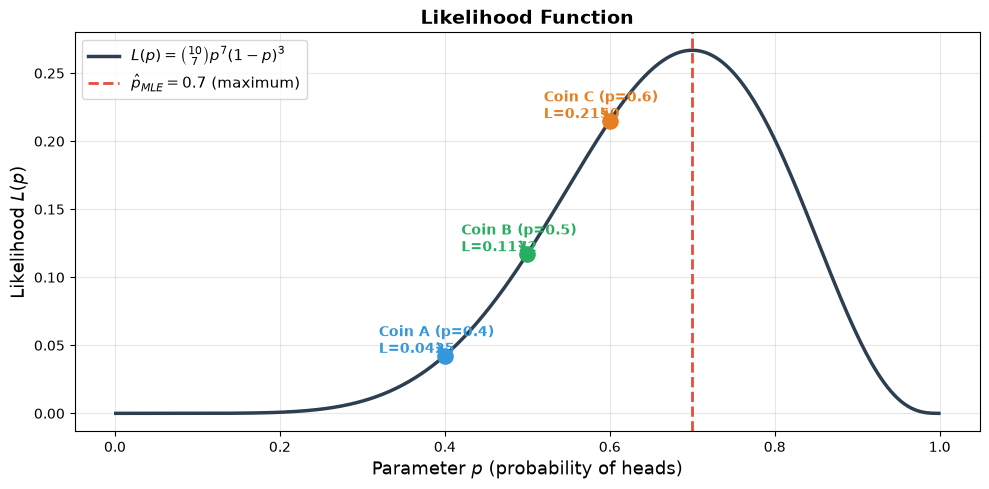

MLE estimate: p_hat = 0.7 (i.e., sample frequency k/n)
This matches intuition: 7 heads in 10 tosses -> the most reasonable estimate for p is 7/10 = 0.7


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb

# Experiment data: 10 tosses, 7 heads
n, k = 10, 7

# Compute likelihood over p in [0, 1]
p_range = np.linspace(0.001, 0.999, 500)
likelihood = comb(n, k) * (p_range ** k) * ((1 - p_range) ** (n - k))

# Find the maximum
p_mle = k / n  # theoretical maximum at p = k/n = 0.7

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(p_range, likelihood, '#2C3E50', linewidth=2.5, label=r'$L(p) = \binom{10}{7} p^7 (1-p)^3$')
ax.axvline(x=p_mle, color='#E74C3C', linestyle='--', linewidth=2,
           label=fr'$\hat{{p}}_{{MLE}} = {p_mle}$ (maximum)')

# Mark the three coins
coins = {'A': 0.4, 'B': 0.5, 'C': 0.6}
colors = ['#3498DB', '#27AE60', '#E67E22']
for (name, p_val), c in zip(coins.items(), colors):
    l_val = comb(n, k) * (p_val ** k) * ((1 - p_val) ** (n - k))
    ax.scatter([p_val], [l_val], c=c, s=120, zorder=5)
    ax.annotate(f'Coin {name} (p={p_val})\nL={l_val:.4f}',
                xy=(p_val, l_val), fontsize=10, fontweight='bold', color=c,
                xytext=(p_val - 0.08, l_val + 0.002),
                arrowprops=dict(arrowstyle='->', color=c, lw=1.5))

ax.set_xlabel(r'Parameter $p$ (probability of heads)', fontsize=13)
ax.set_ylabel(r'Likelihood $L(p)$', fontsize=13)
ax.set_title('Likelihood Function', fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"MLE estimate: p_hat = {p_mle} (i.e., sample frequency k/n)")
print(f"This matches intuition: 7 heads in 10 tosses -> the most reasonable "
      f"estimate for p is 7/10 = {p_mle}")

### 4.1.3 极大似然估计的思想与形式化

从掷硬币的例子中，我们可以提炼出一个普适的思路：

> **给定一组观测数据，我们想知道什么样的参数 $\theta$ 最有可能产生这组数据。答案就是：使似然函数 $L(\theta)$ 取到最大值的那个 $\hat{\theta}$。**

这个想法和我们训练神经网络的目标是**不谋而合的**——我们有一组训练数据 $\{(x_i, y_i)\}$，有一个模型 $f(x; \phi)$（参数为 $\phi$），我们想要找到一组参数 $\phi$，使得模型对训练数据的"解释能力"最大。

---



#### 形式化定义

设有 $n$ 个**独立同分布**（i.i.d.）的样本 $x_1, x_2, \ldots, x_n$，它们来自某个概率分布，其概率密度函数（连续型）或分布律（离散型）为 $f(x; \theta)$，其中 $\theta$ 是未知参数。

**似然函数（Likelihood Function）** 定义为所有样本的联合概率密度：

$$
\boxed{L(\theta) = \prod_{i=1}^{n} f(x_i; \theta)}
$$

这里使用分号 $f(x; \theta)$ 而不是竖线 $f(x|\theta)$，是为了强调：**$\theta$ 是变量（未知参数），$x_i$ 是固定的（已知观测值）**。$\theta$ 不是一个随机变量，而是一个待估计的确定值。

> **为什么是连乘？** 因为样本之间是独立的，根据概率论，多个独立事件同时发生的概率等于各自概率的乘积：
> $$P(A \cap B) = P(A) \cdot P(B) \quad \text{（当 A 和 B 独立时）}$$
>
> 所以 $n$ 个独立样本的联合概率就是 $n$ 个单独概率的连乘积。

**极大似然估计量（MLE Estimator）** $\hat{\theta}_{\text{MLE}}$ 就是使似然函数取最大值的 $\theta$：

$$
\boxed{\hat{\theta}_{\text{MLE}} = \underset{\theta}{\arg\max} \; L(\theta) = \underset{\theta}{\arg\max} \prod_{i=1}^{n} f(x_i; \theta)}
$$

---




#### 为什么取对数？

在实际计算中，连乘会带来两个严重问题：

1. **数值下溢**：每个 $f(x_i; \theta)$ 都是小于 1 的概率值，$n$ 个这样的值相乘，结果会迅速趋近于 $0$，超出计算机的浮点精度
2. **求导困难**：连乘的导数计算非常繁琐（需要用到乘法法则展开）

**解决方案**：取对数。因为 $\log$ 是单调递增函数，不改变极值点的位置（见图 5.2）。

由此得到**对数似然函数（Log-Likelihood Function）**：

$$
\boxed{\ell(\theta) = \log L(\theta) = \log \prod_{i=1}^{n} f(x_i; \theta) = \sum_{i=1}^{n} \log f(x_i; \theta)}
$$

因此 MLE 的求解等价于：

$$
\hat{\theta}_{\text{MLE}} = \underset{\theta}{\arg\max} \; \ell(\theta) = \underset{\theta}{\arg\max} \sum_{i=1}^{n} \log f(x_i; \theta)
$$

> **注意**：在机器学习中，我们习惯**最小化**损失函数而不是最大化。因此将最大化对数似然取负号，转化为**最小化负对数似然（Negative Log-Likelihood, NLL）**：
>
> $$\hat{\theta}_{\text{MLE}} = \underset{\theta}{\arg\min} \; \Big[-\sum_{i=1}^{n} \log f(x_i; \theta)\Big]$$
>
> 这就是损失函数的形式！后面我们会反复看到这个模式。

### 4.1.4 极大似然估计的求解步骤

总结起来，MLE 的求解分为以下四个步骤：

| 步骤 | 操作 | 说明 |
|:---:|:---|:---|
| **1** | **写出似然函数** | 根据数据的概率分布，写出联合概率 $L(\theta) = \prod_{i=1}^{n} f(x_i; \theta)$ |
| **2** | **取对数** | 得到对数似然 $\ell(\theta) = \sum_{i=1}^{n} \log f(x_i; \theta)$ |
| **3** | **求导数** | 对 $\ell(\theta)$ 关于 $\theta$ 求偏导，令 $\frac{\partial \ell}{\partial \theta} = 0$，得到似然方程 |
| **4** | **解方程** | 解出 $\hat{\theta}$，即为极大似然估计值 |

> **注意**：当似然函数不可导时（如均匀分布），需要根据具体情况直接分析似然函数的最大值点，不能直接套用求导步骤。

---

---

## 4.2 从极大似然推导线性回归的损失函数

有了 4.1 节的铺垫，我们现在可以回答本章最核心的问题了：

> **线性回归中那个熟知的 MSE 损失函数，到底是怎么来的？**

答案是：**它来自于"假设误差服从正态分布 + 极大似然估计"**。下面我们一步步来推导。

---

### 4.2.1 问题设定

考虑一个标准的线性回归问题。我们有 $n$ 个训练样本 $\{(\mathbf{x}_1, y_1), (\mathbf{x}_2, y_2), \ldots, (\mathbf{x}_n, y_n)\}$，其中：

- $\mathbf{x}_i \in \mathbb{R}^d$：第 $i$ 个样本的输入特征向量（$d$ 维）
- $y_i \in \mathbb{R}$：第 $i$ 个样本的目标值（标量）

我们用一个线性模型来拟合数据：

$$f(\mathbf{x}_i; \mathbf{w}) = \mathbf{w}^T \mathbf{x}_i$$

其中 $\mathbf{w} \in \mathbb{R}^d$ 是模型的权重参数（为简化记号，这里省略了偏置项 $b$，可以将其吸收进 $\mathbf{w}$ 和 $\mathbf{x}$ 中——在 $\mathbf{x}$ 末尾补一个常数 $1$ 即可）。

### 4.2.2 高斯噪声假设

在现实世界中，我们的线性模型 $\mathbf{w}^T \mathbf{x}_i$ 不可能完美地拟合每一个数据点。真实值 $y_i$ 和预测值 $\mathbf{w}^T \mathbf{x}_i$ 之间总会存在一个偏差——我们称之为**噪声**或**误差**。

我们不再是简单地"让预测值逼近真实值"，而是换一个角度：**对误差的分布做出概率假设**。

具体地，我们假设每个样本的误差 $\epsilon_i = y_i - \mathbf{w}^T \mathbf{x}_i$ 服从**均值为 0、方差为 $\sigma^2$ 的正态分布**：

$$\epsilon_i = y_i - \mathbf{w}^T \mathbf{x}_i \sim \mathcal{N}(0, \sigma^2)$$

这个假设意味着什么？

- **均值为 0**：误差在正负两个方向上是"公平"的——模型不会系统性地高估或低估
- **方差 $\sigma^2$ 恒定**（同方差假设 / homoscedasticity）：每个样本点的噪声大小是相同的

在给定输入 $\mathbf{x}_i$ 和参数 $\mathbf{w}$ 的条件下，目标值 $y_i$ 的条件分布为：

$$y_i \mid \mathbf{x}_i; \mathbf{w} \sim \mathcal{N}(\mathbf{w}^T \mathbf{x}_i,\; \sigma^2)$$

即：**在给定 $\mathbf{x}_i$ 的条件下，$y_i$ 服从均值为 $\mathbf{w}^T \mathbf{x}_i$、方差为 $\sigma^2$ 的正态分布。**

其概率密度函数为：

$$\boxed{f(y_i \mid \mathbf{x}_i; \mathbf{w}, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left\{-\frac{(y_i - \mathbf{w}^T \mathbf{x}_i)^2}{2\sigma^2}\right\}}$$

> **这里 $\mathbf{w}$ 是我们想要求解的未知参数**，$\sigma^2$ 暂时视为已知常数（后面会说明它不影响最终结果）。分号后面的 $\mathbf{w}$ 和 $\sigma^2$ 是变量，分号前面的 $y_i$ 和 $\mathbf{x}_i$ 是已知观测值——这正是似然函数的视角。

### 4.2.3 构建似然函数

假设 $n$ 个样本是**独立**的（这是极大似然估计的关键前提），则似然函数为各样本条件概率密度的连乘积：

$$
\boxed{L(\mathbf{w}) = \prod_{i=1}^{n} f(y_i \mid \mathbf{x}_i; \mathbf{w}, \sigma^2) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left\{-\frac{(y_i - \mathbf{w}^T \mathbf{x}_i)^2}{2\sigma^2}\right\}}
$$

> **注意**：这里 $\mathbf{w}$ 是变量（我们要找的），$\{(\mathbf{x}_i, y_i)\}$ 是已知数据。这正对应于 4.1 节中强调的"似然"视角——数据固定，参数可变。

---

### 4.2.4 从极大似然到最小二乘

接下来取对数，将连乘转化为连加：

$$
\begin{aligned}
\ell(\mathbf{w}) = \log L(\mathbf{w}) &= \sum_{i=1}^{n} \log\left[\frac{1}{\sqrt{2\pi\sigma^2}} \exp\left\{-\frac{(y_i - \mathbf{w}^T \mathbf{x}_i)^2}{2\sigma^2}\right\}\right] \\[6pt]
&= \sum_{i=1}^{n} \left[\log\frac{1}{\sqrt{2\pi\sigma^2}} - \frac{(y_i - \mathbf{w}^T \mathbf{x}_i)^2}{2\sigma^2}\right] \\[6pt]
&= -\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^{n} (y_i - \mathbf{w}^T \mathbf{x}_i)^2
\end{aligned}
$$

---

**关键一步**：现在我们要找到 $\hat{\mathbf{w}}_{\text{MLE}}$，使得对数似然 $\ell(\mathbf{w})$ 最大化：

$$\hat{\mathbf{w}}_{\text{MLE}} = \underset{\mathbf{w}}{\arg\max} \; \ell(\mathbf{w})$$

观察 $\ell(\mathbf{w})$ 的结构：
- 第一项 $-\frac{n}{2}\log(2\pi\sigma^2)$ 与 $\mathbf{w}$ **无关**，可以去掉
- 第二项 $-\frac{1}{2\sigma^2}\sum_{i=1}^{n} (y_i - \mathbf{w}^T \mathbf{x}_i)^2$ 中，因子 $-\frac{1}{2\sigma^2}$ 是负的常数，**不影响极值点位置**

因此：

$$
\begin{aligned}
\hat{\mathbf{w}}_{\text{MLE}} &= \underset{\mathbf{w}}{\arg\max} \; \left[-\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^{n} (y_i - \mathbf{w}^T \mathbf{x}_i)^2\right] \\[6pt]
&= \underset{\mathbf{w}}{\arg\max} \; \left[-\sum_{i=1}^{n} (y_i - \mathbf{w}^T \mathbf{x}_i)^2\right] \\[6pt]
&= \underset{\mathbf{w}}{\arg\min} \; \sum_{i=1}^{n} (y_i - \mathbf{w}^T \mathbf{x}_i)^2
\end{aligned}
$$

---

**我们得到了什么？**

$$
\boxed{\hat{\mathbf{w}}_{\text{MLE}} = \underset{\mathbf{w}}{\arg\min} \sum_{i=1}^{n} \big(y_i - \mathbf{w}^T \mathbf{x}_i\big)^2}
$$

这就是**最小二乘法（Least Squares）**！取均值后就是我们熟知的 **MSE（Mean Squared Error）**：

$$\boxed{\mathcal{L}(\mathbf{w}) = \frac{1}{n}\sum_{i=1}^{n} \big(y_i - \mathbf{w}^T \mathbf{x}_i\big)^2}$$

---

> 在线性回归中，MSE 损失函数**不是凭空捏造的**，它来自于三个假设：
>
> 1. **误差服从正态分布**：$\epsilon \sim \mathcal{N}(0, \sigma^2)$
> 2. **样本独立同分布**（i.i.d.）
> 3. **极大似然估计**：寻找让数据出现概率最大的参数
>
> 在这三个前提下，最大化似然**等价于**最小化平方误差。这就是 MSE 作为线性回归损失函数的**概率论基础**。

---

## 4.3 小结与展望

本章我们从极大似然估计（MLE）出发，完成了一次"损失函数探源之旅"：

### 我们学到了什么

1. **概率 vs 似然**：概率是"给定参数，推测数据"；似然是"给定数据，反推参数"。这是理解整个框架的钥匙。

2. **极大似然估计（MLE）**：选择使观测数据出现概率最大的参数。步骤为：写出似然函数 → 取对数 → 求导 → 解方程。

3. **线性回归的 MSE 来自正态假设**：当假设误差服从正态分布 $\mathcal{N}(0, \sigma^2)$ 时，极大似然估计**等价于**最小化平方误差。MSE 不是凭空捏造的，而是概率假设的必然结果。

4. **UDL 的损失函数配方**：
   > ① 选择一个适合输出域的概率分布 → ② 让模型预测该分布的参数 → ③ 最小化负对数似然 → ④ 推理时返回分布的最大值点

### 通往下一章的桥梁

本章只完成了"配方"的第一步应用——单变量回归 + 正态分布 → 最小二乘。这个框架的威力远不止于此：

| 任务类型 | 选择分布 | 导出的损失函数 |
|:---|:---|:---|
| 回归（连续值） | 正态分布 $\mathcal{N}(\mu, \sigma^2)$ | **MSE**（最小二乘） |
| 回归（鲁棒） | 拉普拉斯分布 | **MAE** |
| 二分类 | 伯努利分布 | **二分类交叉熵** |
| 多分类 | 类别分布 + Softmax | **多分类交叉熵** |

后续章节我们将逐步展开二分类和多分类的交叉熵损失函数推导。有了本章的框架，这些推导将变得自然而然——**只需换一个概率分布，损失函数就自然浮现了**。

> **核心思想**：从第三章到本章，我们建立了两条并行线索——
> - **模型**：从浅层网络到深层网络，决定了"函数长什么样"（UDL 第 3-4 章）
> - **损失**：从极大似然到具体损失函数，决定了"什么叫拟合得好"（UDL 第 5 章）
>
> 有了模型和损失，下一章我们将讨论如何**训练**——即如何找到使损失最小的参数（UDL 第 6-7 章：梯度下降与反向传播）。